In [1]:
##Step 1: Import Libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
##Step 2: Load Dataset
df = pd.read_csv("dataset/lung_cancer.csv")

In [4]:
##Step 3: Data Preprocessing
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [5]:
##Step 4: Split Features & Target
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

In [6]:
##Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
##Step 6: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
##----Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [10]:
##-----Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
##------SVM
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [12]:
##Step 7 : Evaluation
from sklearn.metrics import accuracy_score, classification_report

models = [lr, rf, svm]

for model in models:
    y_pred = model.predict(X_test)
    print(model.__class__.__name__)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

LogisticRegression
Accuracy: 0.967741935483871
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62

RandomForestClassifier
Accuracy: 0.967741935483871
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62

SVC
Accuracy: 0.9516129032258065
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.98      0.97      0.97        60

    accuracy                           0.95        

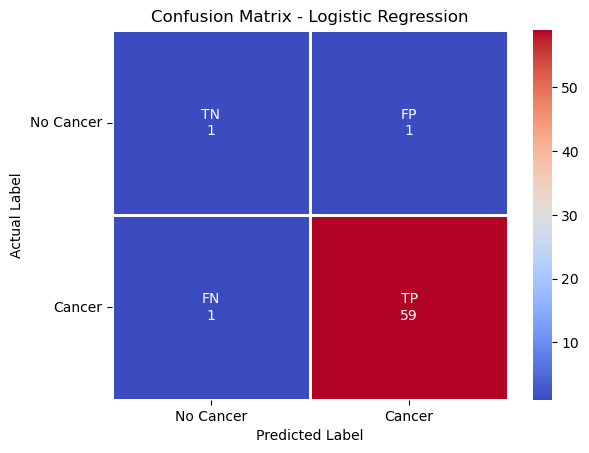

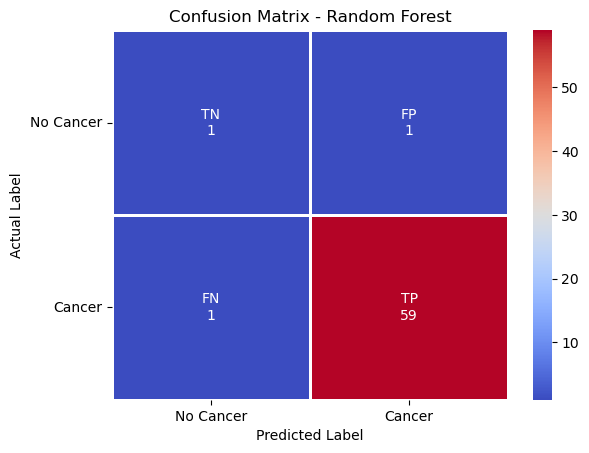

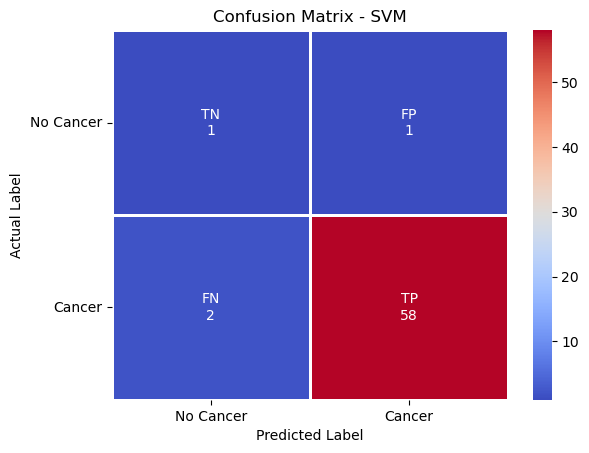

In [23]:
##---Confusion Matrix-----##
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Create labels with values
    labels = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    annotated = np.empty_like(cm).astype(str)

    for i in range(2):
        for j in range(2):
            annotated[i, j] = f"{labels[i, j]}\n{cm[i, j]}"

    plt.figure()
    sns.heatmap(cm, annot=annotated, fmt='', cmap='coolwarm', linewidths=1)

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks([0.5, 1.5], ["No Cancer", "Cancer"])
    plt.yticks([0.5, 1.5], ["No Cancer", "Cancer"], rotation=0)

    plt.show()

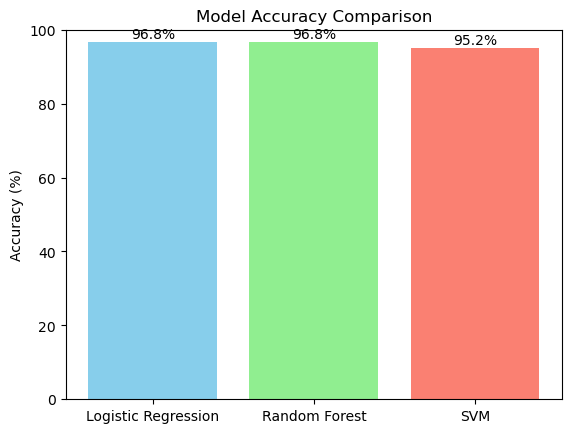

In [24]:
#Accuracy Comparison Bar Chart
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

names = []
scores = []

# Calculate accuracy
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    names.append(name)
    scores.append(acc)

# Define colors for each bar
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure()
bars = plt.bar(names, scores, color=colors)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{height:.1f}%', ha='center')

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

plt.show()


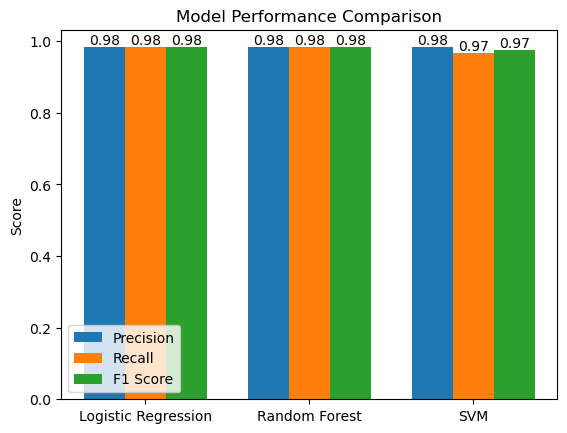

In [28]:
#Precision, Recall, F1 Comparison
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

precision = []
recall = []
f1 = []
names = []

# Calculate metrics
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))
    names.append(name)

# Bar positions
x = np.arange(len(names))
width = 0.25

plt.figure()

bars1 = plt.bar(x - width, precision, width, label='Precision')
bars2 = plt.bar(x, recall, width, label='Recall')
bars3 = plt.bar(x + width, f1, width, label='F1 Score')

# Add values on top
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom')

plt.xticks(x, names)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

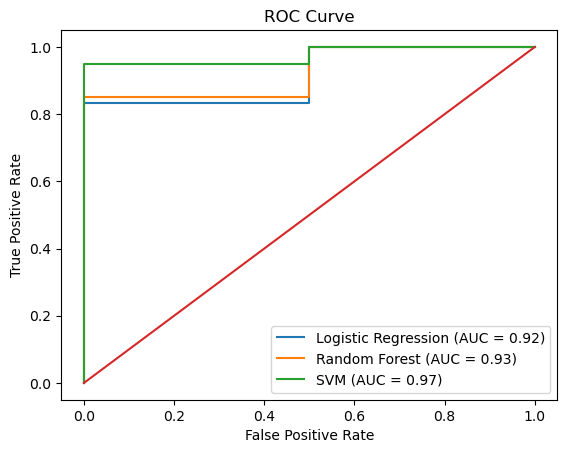

In [18]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

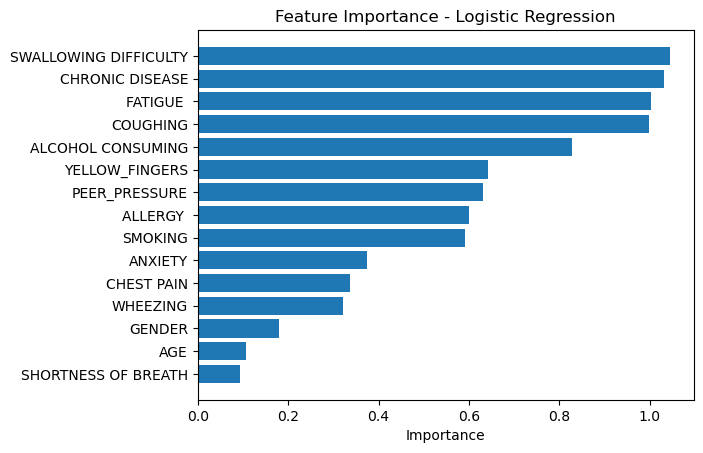

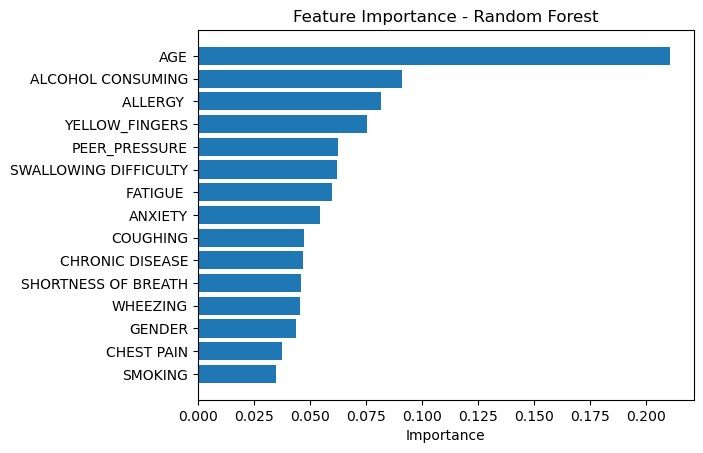

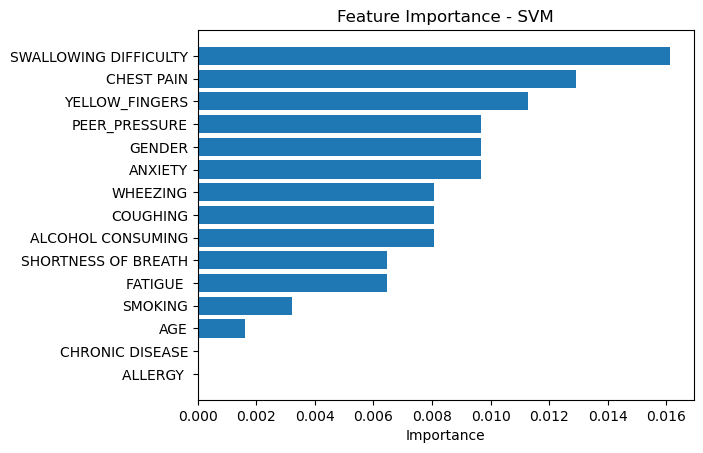

In [27]:
#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def plot_importance(df, title):
    plt.figure()
    plt.barh(df["Feature"], df["Importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

# 1. LOGISTIC REGRESSION

lr_importance = abs(lr.coef_[0])  # take absolute for clean comparison

lr_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lr_importance
}).sort_values(by="Importance", ascending=False)

plot_importance(lr_df, "Feature Importance - Logistic Regression")

# 2. RANDOM FOREST

rf_importance = rf.feature_importances_

rf_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

plot_importance(rf_df, "Feature Importance - Random Forest")

# 3. SVM (Permutation Importance)

svm_result = permutation_importance(svm, X_test, y_test, n_repeats=10, random_state=42)

svm_importance = abs(svm_result.importances_mean)
svm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": svm_importance
}).sort_values(by="Importance", ascending=False)

plot_importance(svm_df, "Feature Importance - SVM")

In [29]:
prediction = rf.predict(X_test)

In [30]:
output = ["YES" if p == 1 else "NO" for p in prediction]
print(output[:10])

['YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES']


In [31]:
sample = [55, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1]  # example values

sample = scaler.transform([sample])  # scale it

result = rf.predict(sample)[0]

if result == 1:
    print("Lung Cancer: YES")
else:
    print("Lung Cancer: NO")

Lung Cancer: YES


C:\Users\NAVYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
import joblib

joblib.dump(rf, "lung_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']